# 51 — Expert Opto Analysis

Expert-phase optogenetic inactivation of PPC during 2-AFC sound categorisation.

**Design:** VGAT-ChR2-EYFP transgenic mice. Het animals express ChR2 in GABAergic neurons (light → cortical silencing). WT littermates receive identical light delivery (masking control). 30% of trials are opto-on, interleaved.

**Prediction:** PPC is dispensable during expert performance — no opto effect expected in either genotype.

**Analyses:**
1. QC — trial proportions, session counts, data integrity
2. Within-animal, within-session — opto vs control trials
3. Within-animal, across-session — masking vs baseline vs opto stability
4. Between-animal — het vs WT genotype interaction
5. Cohort summary — null prediction testing (t-test + Mann-Whitney + TOST)
6. Additional analyses — stimulus-conditional, carry-over, RT, bias

## 0 — Setup

In [1]:
from shared_setup import *
from scipy.stats import mannwhitneyu, ttest_ind, ttest_1samp, chi2_contingency

from analysis.opto import (
    OptoPhase,
    assign_opto_phases,
    split_trials_by_opto,
    extract_trial_arrays,
    within_session_effect,
    phase_pooled_comparison,
    compute_opto_um,
    expert_stability,
    animal_opto_report,
    cohort_opto_report,
    genotype_interaction,
    expert_null_test,
    expert_um_test,
)

from plotting.opto import (
    plot_opto_psychometric,
    plot_phase_trajectory,
    plot_opto_um_comparison,
    plot_expert_stability,
    plot_within_session_summary,
    plot_genotype_interaction,
    plot_equivalence_test,
    plot_animal_opto_report,
    OPTO_COLOUR,
    CTRL_COLOUR,
    PHASE_COLOURS,
)

In [2]:
experiment, info = load_data()
print(f'Mode: {info["mode"]}')

Loaded snapshot: 22 animals, 1043 sessions (exported 2026-05-11)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:194: UserWarning: Config has changed since snapshot was exported. Re-export if column mappings changed.
  experiment, meta = load_snapshot(


In [3]:
# Identify opto animals: those with at least one session containing opto trials
opto_animals = {}
for aid, animal in experiment.animals.items():
    has_opto = any(
        hasattr(s.trials, 'opto_on') and np.any(s.trials.opto_on)
        for s in animal.sessions
    )
    if has_opto:
        opto_animals[aid] = animal

print(f'Opto animals: {len(opto_animals)} / {experiment.n_animals}')
for aid, animal in sorted(opto_animals.items()):
    geno = animal.genotype
    n_opto_sess = sum(
        1 for s in animal.sessions
        if hasattr(s.trials, 'opto_on') and np.any(s.trials.opto_on)
    )
    print(f'  {aid}: {geno}, {animal.n_sessions} total sessions, '
          f'{n_opto_sess} opto sessions')

Opto animals: 6 / 22
  SS01: unknown, 81 total sessions, 1 opto sessions
  SS04: unknown, 99 total sessions, 1 opto sessions
  SS10: unknown, 62 total sessions, 1 opto sessions
  SS11: unknown, 63 total sessions, 1 opto sessions
  SS13: unknown, 63 total sessions, 1 opto sessions
  SS18: unknown, 28 total sessions, 1 opto sessions


In [4]:
# Run reports for all opto animals
reports = {}
for aid, animal in opto_animals.items():
    reports[aid] = animal_opto_report(animal)

# Separate by genotype
het_animals = {aid: a for aid, a in opto_animals.items() if a.genotype == 'het'}
wt_animals = {aid: a for aid, a in opto_animals.items() if a.genotype == 'wt'}
print(f'Het: {len(het_animals)}, WT: {len(wt_animals)}')

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


Het: 0, WT: 0


---
## 1 — Quality Control

In [5]:
# 1a: Verify opto trial proportions and trial counts
print(f'{"Animal":<8} {"Genotype":<10} {"Session":<10} {"Phase":<20} '
      f'{"n_opto":<8} {"n_ctrl":<8} {"opto%":<8} {"n_abort":<8} {"n_noresp":<8}')
print('-' * 100)

for aid in sorted(reports):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']
    for idx, (sess, phase) in enumerate(zip(animal.sessions, phases)):
        if phase not in (OptoPhase.EXPERT_OPTO, OptoPhase.MASKING):
            continue
        opto_mask, ctrl_mask = split_trials_by_opto(sess)
        n_opto = opto_mask.sum()
        n_ctrl = ctrl_mask.sum()
        total_valid = n_opto + n_ctrl
        pct = 100 * n_opto / total_valid if total_valid > 0 else 0
        n_abort = sess.trials.abort.sum()
        n_noresp = sess.trials.no_response.sum()
        print(f'{aid:<8} {animal.genotype:<10} {idx:<10} {phase.value:<20} '
              f'{n_opto:<8} {n_ctrl:<8} {pct:<8.1f} {n_abort:<8} {n_noresp:<8}')

Animal   Genotype   Session    Phase                n_opto   n_ctrl   opto%    n_abort  n_noresp
----------------------------------------------------------------------------------------------------
SS01     unknown    45         expert_opto          123      280      30.5     46       0       
SS04     unknown    63         expert_opto          89       186      32.4     81       2       
SS10     unknown    26         expert_opto          48       134      26.4     72       0       
SS11     unknown    27         expert_opto          67       159      29.6     61       0       
SS13     unknown    27         expert_opto          85       198      30.0     71       0       


In [6]:
# 1b: Phase assignment summary
from collections import Counter

for aid in sorted(reports):
    phases = reports[aid]['phases']
    counts = Counter(p.value for p in phases)
    print(f'{aid} ({opto_animals[aid].genotype}): {dict(counts)}')

SS01 (unknown): {'expert_baseline': 45, 'expert_opto': 1, 'expert_washout': 1, 'shift_1_recovery': 17, 'shift_2_recovery': 10}
SS04 (unknown): {'pre_experiment': 2, 'expert_baseline': 61, 'expert_opto': 1, 'expert_washout': 1, 'shift_1_recovery': 17, 'shift_2_recovery': 10}
SS10 (unknown): {'expert_baseline': 26, 'expert_opto': 1, 'expert_washout': 28}
SS11 (unknown): {'expert_baseline': 27, 'expert_opto': 1, 'expert_washout': 4, 'shift_1_recovery': 14, 'shift_2_recovery': 10}
SS13 (unknown): {'expert_baseline': 27, 'expert_opto': 1, 'expert_washout': 4, 'shift_1_recovery': 2, 'shift_2_recovery': 22}


---
## 2 — Within-Animal, Within-Session: Opto vs Control Trials

For each opto session, compare the 30% opto trials against the 70% control trials.

In [7]:
# 2a: Per-session effect sizes (accuracy, PSE, slope)
print(f'{"Animal":<8} {"Geno":<6} {"Sess":<6} {"Phase":<20} '
      f'{"Acc_opto":<10} {"Acc_ctrl":<10} {"Δ_acc":<10} '
      f'{"PSE_opto":<10} {"PSE_ctrl":<10} {"Δ_PSE":<10}')
print('-' * 110)

for aid in sorted(reports):
    for entry in reports[aid]['within_session']:
        if entry['effect'] is None:
            continue
        e = entry['effect']
        print(f'{aid:<8} {opto_animals[aid].genotype:<6} '
              f'{entry["session_idx"]:<6} {entry["phase"].value:<20} '
              f'{e["opto_stats"]["accuracy"]:<10.3f} '
              f'{e["control_stats"]["accuracy"]:<10.3f} '
              f'{e["diff"]["accuracy"]:<10.3f} '
              f'{e["opto_stats"].get("pse", np.nan):<10.3f} '
              f'{e["control_stats"].get("pse", np.nan):<10.3f} '
              f'{e["diff"].get("pse", np.nan):<10.3f}')

Animal   Geno   Sess   Phase                Acc_opto   Acc_ctrl   Δ_acc      PSE_opto   PSE_ctrl   Δ_PSE     
--------------------------------------------------------------------------------------------------------------
SS01     unknown 45     expert_opto          0.772      0.696      0.076      0.180      -0.021     0.201     
SS04     unknown 63     expert_opto          0.787      0.645      0.141      0.055      0.084      -0.029    
SS10     unknown 26     expert_opto          0.667      0.567      0.100      -0.787     0.847      -1.633    
SS11     unknown 27     expert_opto          0.612      0.616      -0.004     -0.544     -0.176     -0.368    
SS13     unknown 27     expert_opto          0.706      0.707      -0.001     0.158      0.013      0.145     


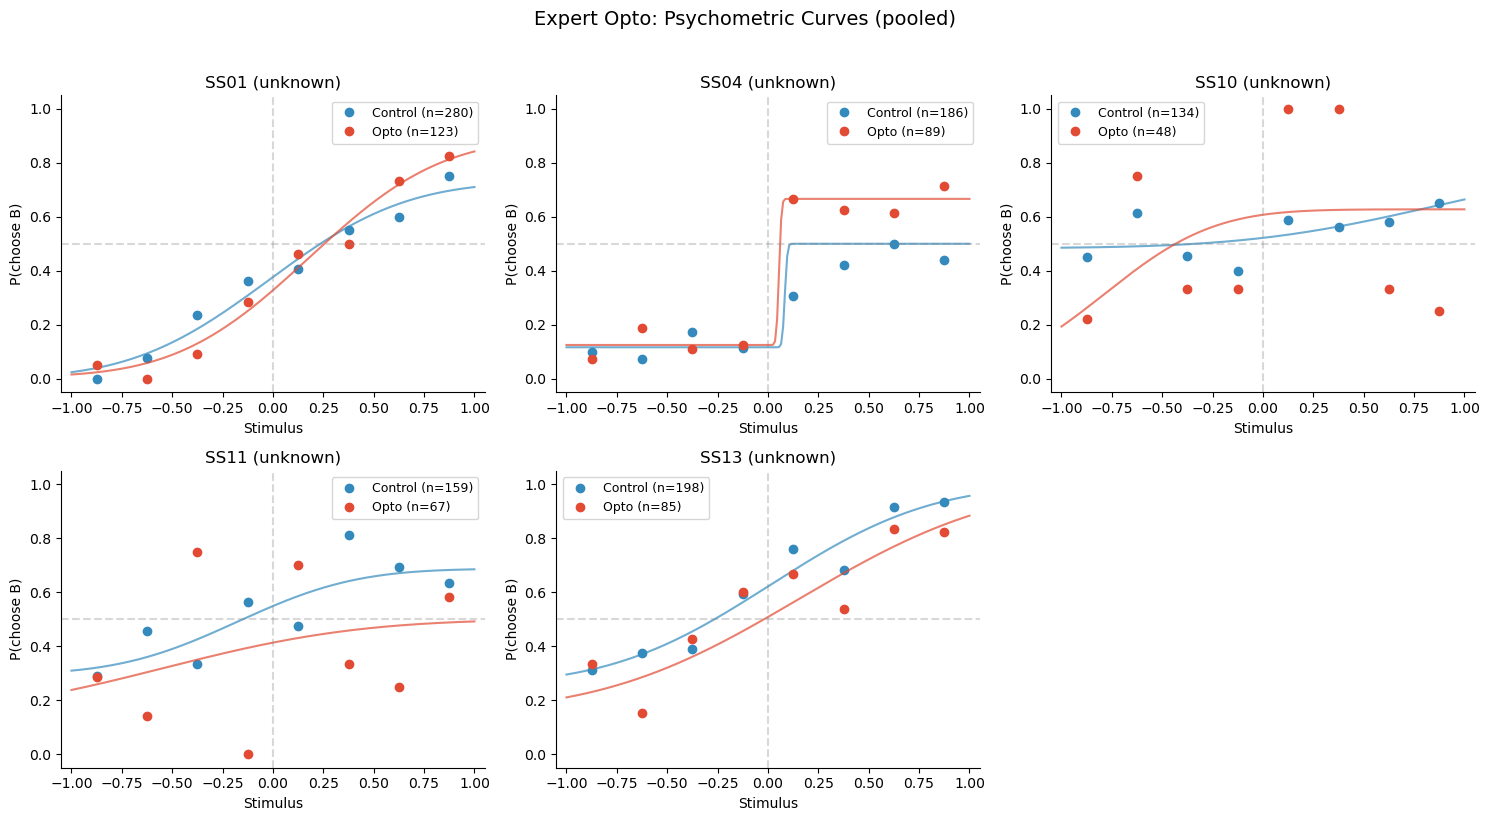

In [8]:
# 2b: Psychometric curves — per animal, pooled across expert opto sessions
n_opto = len(opto_animals)
ncols = min(3, n_opto)
nrows = (n_opto + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)

for idx, aid in enumerate(sorted(opto_animals)):
    ax = axes[idx // ncols, idx % ncols]
    animal = opto_animals[aid]
    phases = reports[aid]['phases']

    expert_opto_sessions = [
        s for s, p in zip(animal.sessions, phases)
        if p == OptoPhase.EXPERT_OPTO
    ]
    if expert_opto_sessions:
        plot_opto_psychometric(
            expert_opto_sessions, ax=ax,
            title=f'{aid} ({animal.genotype})')
    else:
        ax.set_title(f'{aid} — no expert opto sessions')

# Hide unused axes
for idx in range(n_opto, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle('Expert Opto: Psychometric Curves (pooled)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

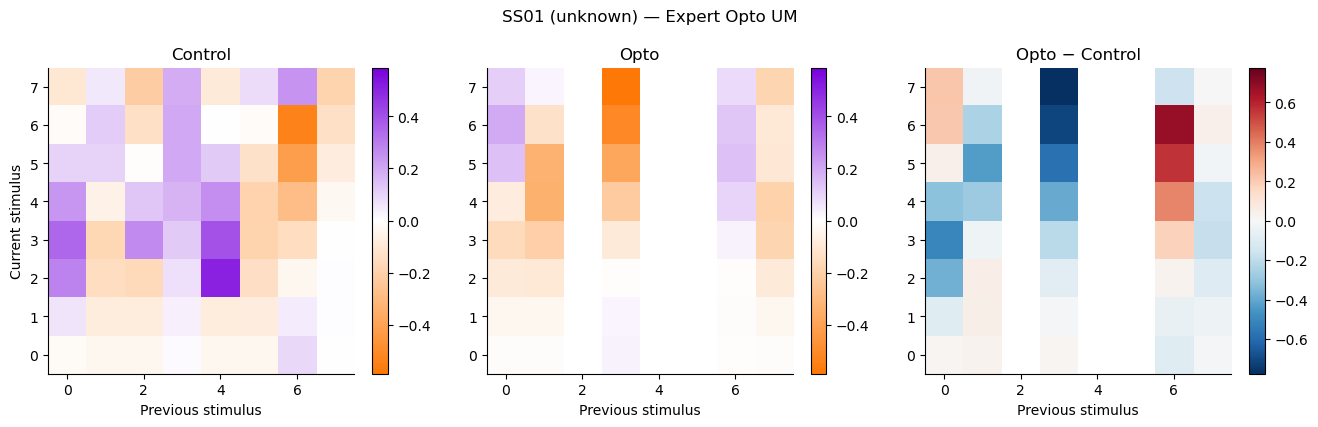

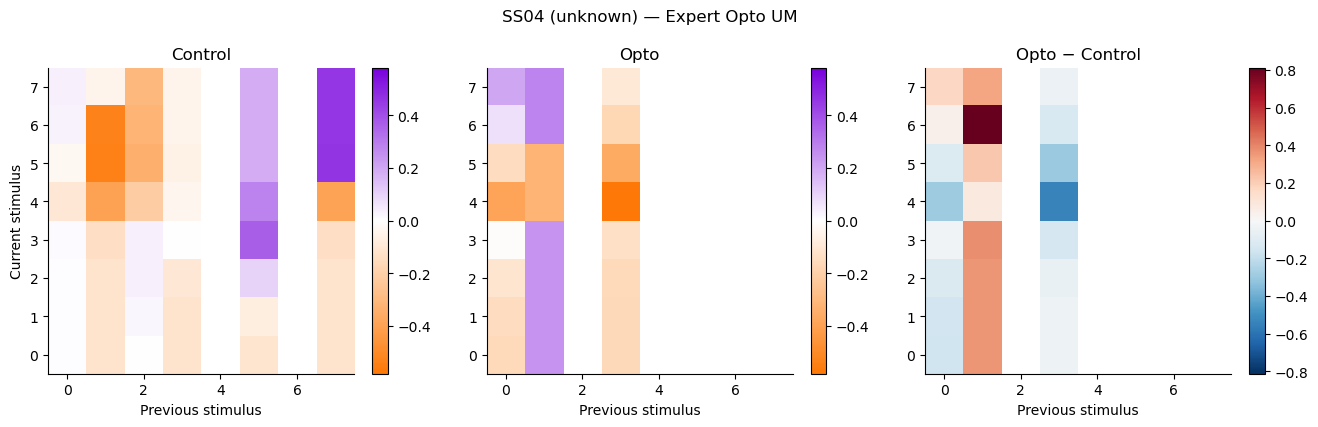

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:225: RuntimeWarning: All-NaN slice encountered
  vmax = max(np.nanmax(np.abs(control_um)), np.nanmax(np.abs(opto_um)))
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:245: RuntimeWarning: All-NaN slice encountered
  vmax_d = max(np.nanmax(np.abs(diff_um)), 0.01)


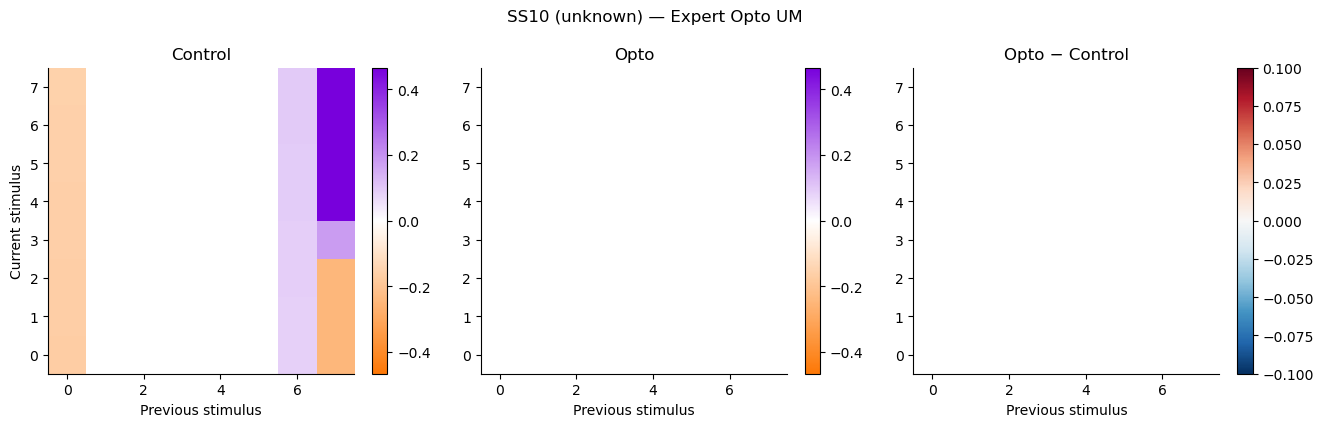

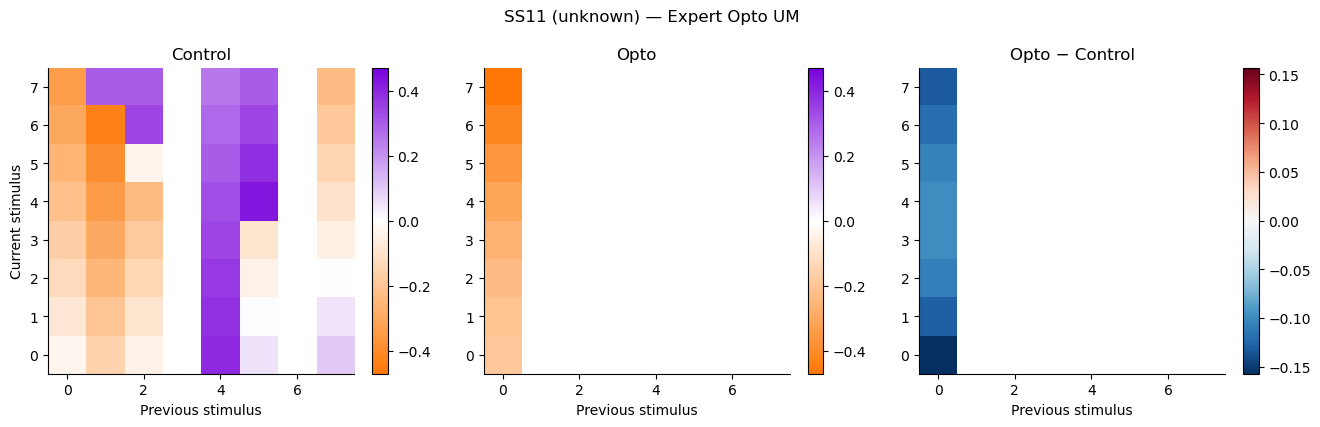

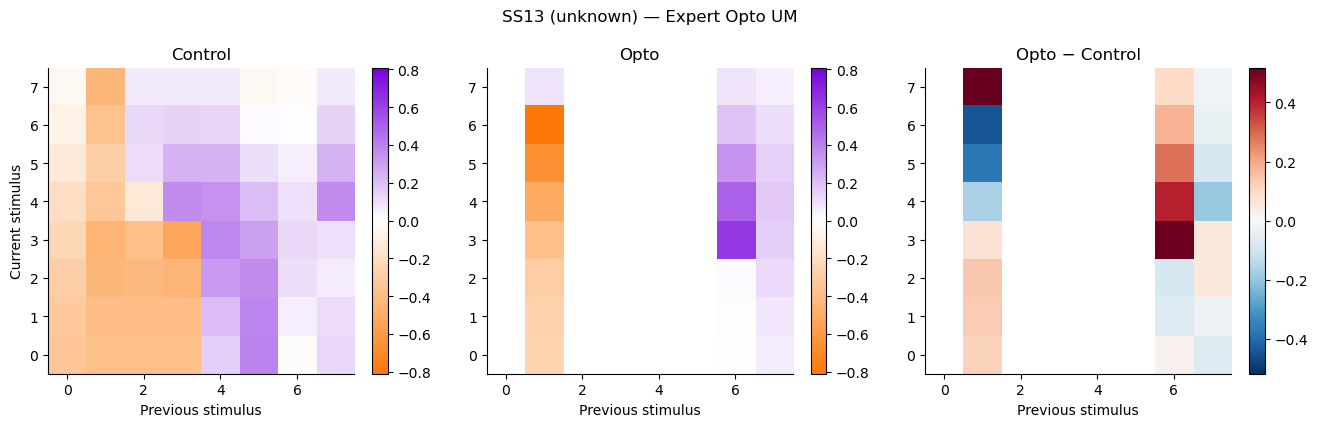

In [9]:
# 2c: Update matrix comparison — pooled expert opto sessions per animal
for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']
    comp = reports[aid]['phase_comparisons'].get(OptoPhase.EXPERT_OPTO)
    if comp is None:
        continue
    fig = plot_opto_um_comparison(
        comp['opto_um'], comp['control_um'],
        title=f'{aid} ({animal.genotype}) — Expert Opto UM')
    plt.show()

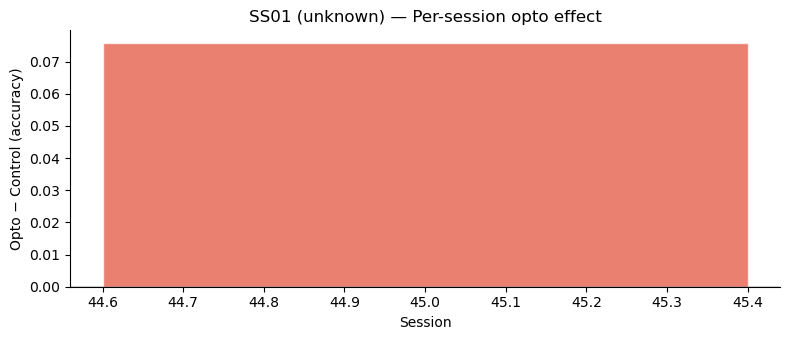

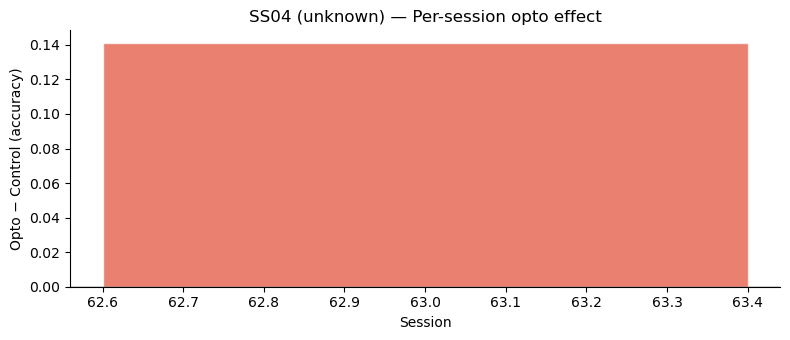

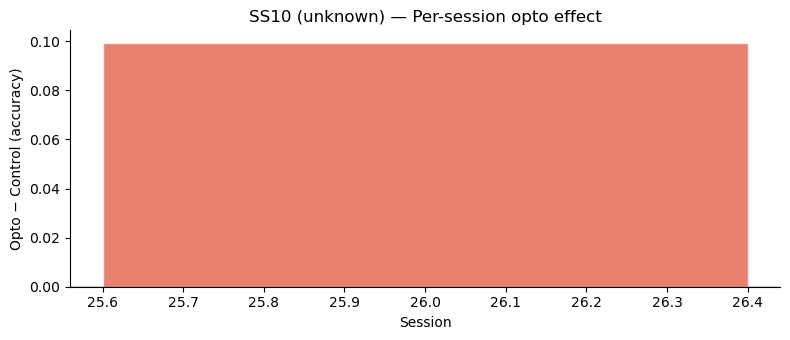

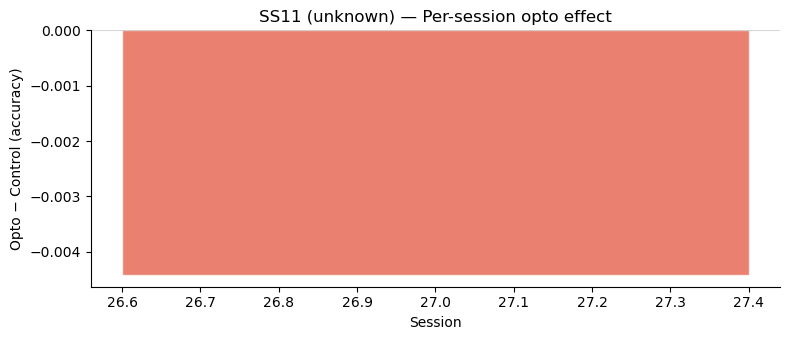

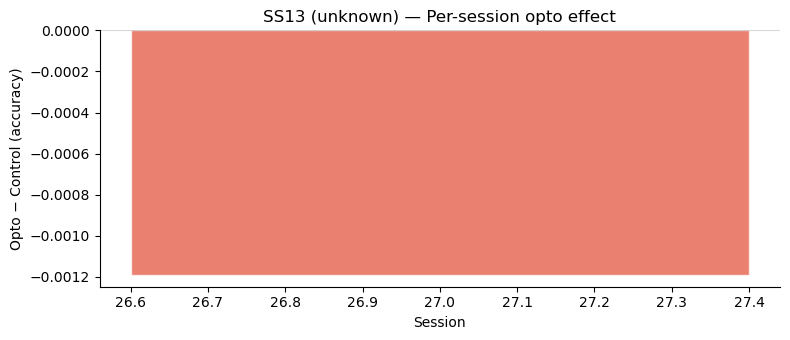

In [10]:
# 2d: Within-session effect bars across sessions
for aid in sorted(opto_animals):
    if not reports[aid]['within_session']:
        continue
    fig = plot_within_session_summary(
        reports[aid]['within_session'], metric='accuracy',
        title=f'{aid} ({opto_animals[aid].genotype}) — Per-session opto effect')
    plt.show()

---
## 3 — Within-Animal, Across-Session: Masking vs Baseline vs Opto

Tests whether:
- Masking sessions differ from baseline (light/heat confound check)
- Control-trial performance is stable across baseline → opto → washout
- The opto effect is stable across repeated opto sessions

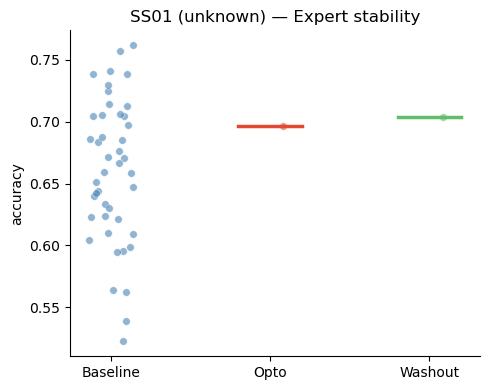

  Baseline: 0.660 (n=45)
  Opto:     0.696 (n=1)
  Washout:  0.704 (n=1)
  p (baseline vs opto): nan



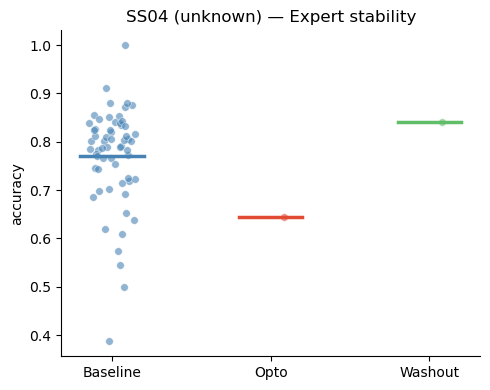

  Baseline: 0.771 (n=61)
  Opto:     0.645 (n=1)
  Washout:  0.841 (n=1)
  p (baseline vs opto): nan



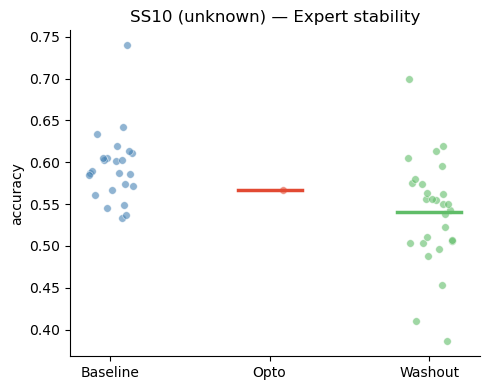

  Baseline: 0.594 (n=26)
  Opto:     0.567 (n=1)
  Washout:  0.540 (n=28)
  p (baseline vs opto): nan



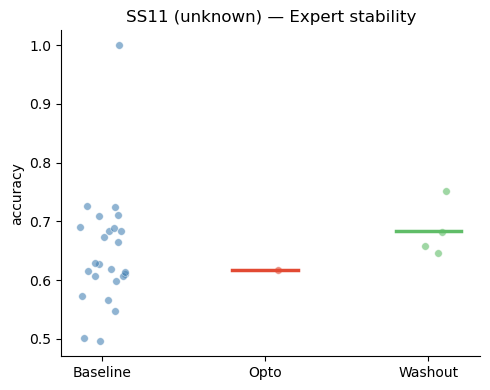

  Baseline: 0.647 (n=27)
  Opto:     0.616 (n=1)
  Washout:  0.684 (n=4)
  p (baseline vs opto): nan



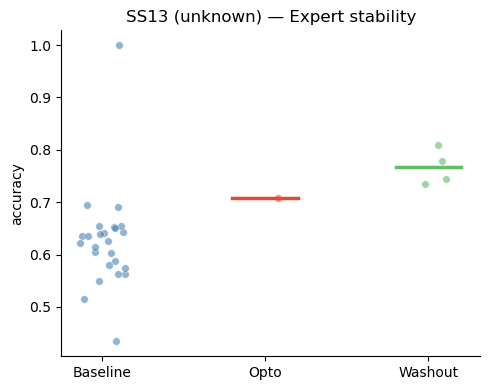

  Baseline: 0.625 (n=27)
  Opto:     0.707 (n=1)
  Washout:  0.766 (n=4)
  p (baseline vs opto): nan



In [11]:
# 3a: Expert stability — baseline vs opto vs washout
for aid in sorted(opto_animals):
    stab = reports[aid]['expert_stability']
    fig = plot_expert_stability(
        stab, stat_name='accuracy',
        title=f'{aid} ({opto_animals[aid].genotype}) — Expert stability')
    plt.show()

    # Print values
    print(f'  Baseline: {stab["baseline_mean"]:.3f} '
          f'(n={len(stab["baseline_values"])})')
    print(f'  Opto:     {stab["opto_mean"]:.3f} '
          f'(n={len(stab["opto_values"])})')
    print(f'  Washout:  {stab["washout_mean"]:.3f} '
          f'(n={len(stab["washout_values"])})')
    print(f'  p (baseline vs opto): {stab.get("p_value", np.nan):.3f}\n')

In [12]:
# 3b: Masking control — do masking sessions differ from baseline?
# Masking sessions should show NO effect (light/heat without neural silencing)
print('Masking vs Baseline comparison (control-trial accuracy):')
print(f'{"Animal":<8} {"Geno":<6} {"Baseline":<12} {"Masking":<12} '
      f'{"Δ":<10} {"n_base":<8} {"n_mask":<8}')
print('-' * 70)

for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']

    baseline_accs = []
    masking_accs = []
    for sess, phase in zip(animal.sessions, phases):
        try:
            st = sess.stats(stat_names=['accuracy'], exclude_opto=True)
            acc = st['accuracy']
        except Exception:
            continue
        if phase == OptoPhase.EXPERT_BASELINE:
            baseline_accs.append(acc)
        elif phase == OptoPhase.MASKING:
            masking_accs.append(acc)

    if not masking_accs:
        continue

    base_mean = np.mean(baseline_accs) if baseline_accs else np.nan
    mask_mean = np.mean(masking_accs)
    diff = mask_mean - base_mean
    print(f'{aid:<8} {animal.genotype:<6} {base_mean:<12.3f} '
          f'{mask_mean:<12.3f} {diff:<10.3f} '
          f'{len(baseline_accs):<8} {len(masking_accs):<8}')

Masking vs Baseline comparison (control-trial accuracy):
Animal   Geno   Baseline     Masking      Δ          n_base   n_mask  
----------------------------------------------------------------------


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


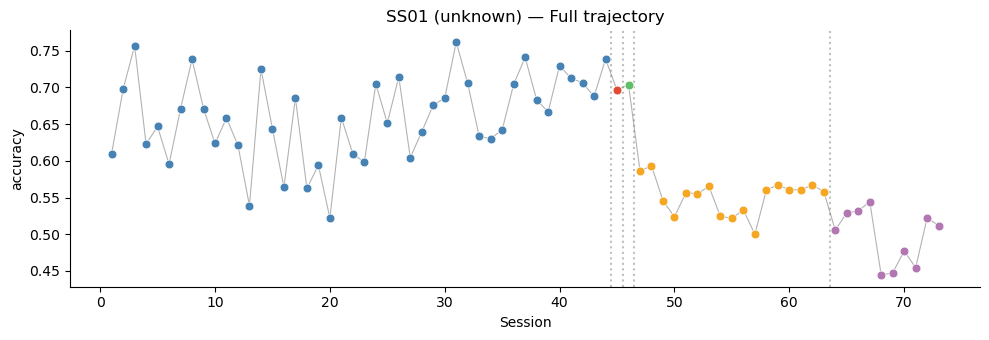

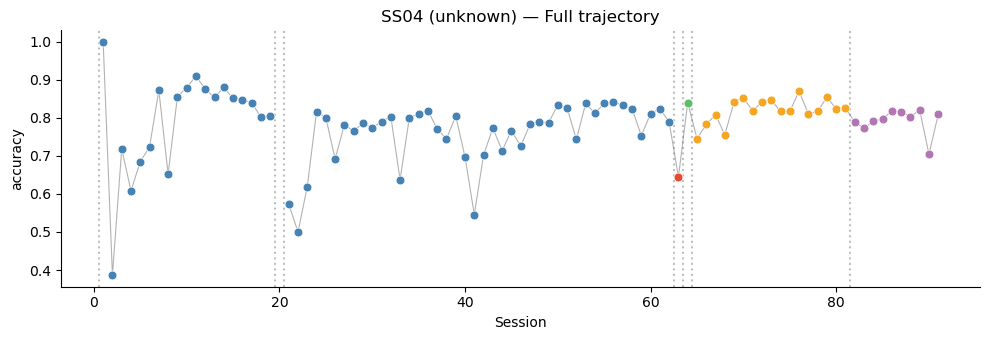

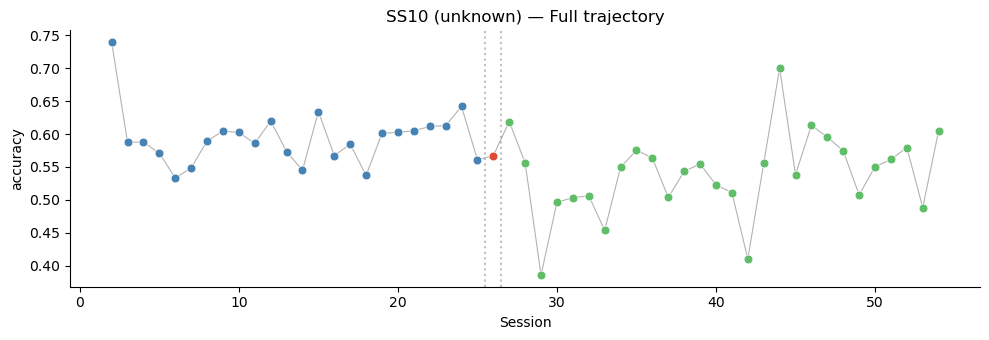

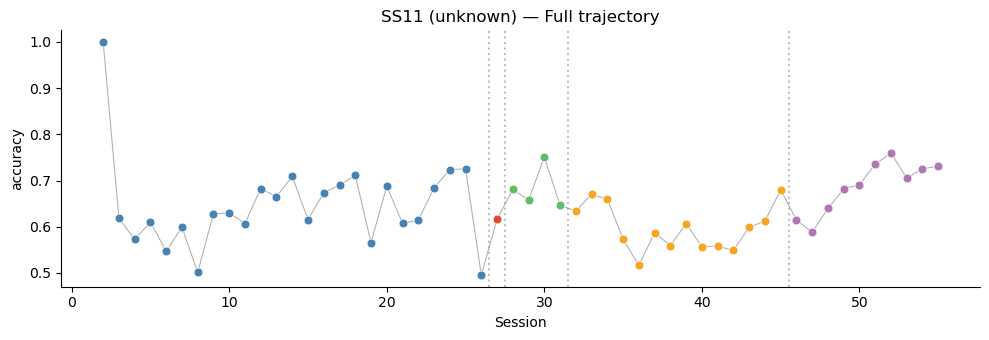

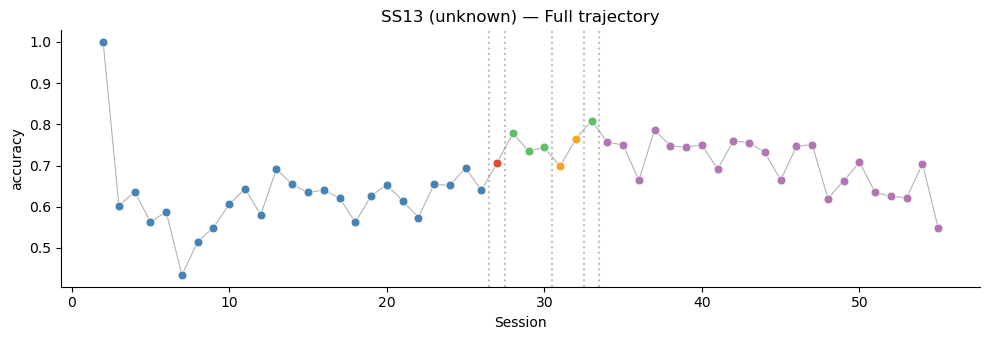

In [13]:
# 3c: Phase trajectory — full session history coloured by phase
for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']
    fig = plot_phase_trajectory(
        animal.sessions, phases, stat_name='accuracy',
        title=f'{aid} ({animal.genotype}) — Full trajectory')
    plt.show()

In [14]:
# 3d: Opto effect stability — does the within-session effect change
#      across repeated opto sessions? (habituation / cumulative damage)
for aid in sorted(opto_animals):
    expert_entries = [
        e for e in reports[aid]['within_session']
        if e['phase'] == OptoPhase.EXPERT_OPTO and e['effect'] is not None
    ]
    if len(expert_entries) < 2:
        continue

    diffs = [e['effect']['diff']['accuracy'] for e in expert_entries]
    sess_idxs = [e['session_idx'] for e in expert_entries]

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(range(len(diffs)), diffs, 'o-', color=OPTO_COLOUR)
    ax.axhline(0, ls='-', color='grey', alpha=0.3)
    ax.set_xlabel('Opto session number')
    ax.set_ylabel('Opto − Control accuracy')
    ax.set_title(f'{aid} ({opto_animals[aid].genotype}) — '
                 f'Effect stability across sessions')

    # Trend test (Spearman correlation with session order)
    if len(diffs) >= 4:
        from scipy.stats import spearmanr
        rho, p = spearmanr(range(len(diffs)), diffs)
        ax.text(0.95, 0.05, f'rho={rho:.2f}, p={p:.3f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=8)

    fig.tight_layout()
    plt.show()

---
## 4 — Between-Animal: Het vs WT

WT animals receive identical light delivery but lack ChR2 expression.
Any "opto effect" in WT animals is artefactual (light/heat).
The critical comparison is het effect size vs WT effect size.

In [15]:
# 4a: Run cohort report (splits by genotype automatically)
cohort = cohort_opto_report(
    experiment,
    target_phase=OptoPhase.EXPERT_OPTO,
    metric='accuracy',
)

print(f'Het animals with expert opto effects: {len(cohort["het_effects"])}')
print(f'WT animals with expert opto effects:  {len(cohort["wt_effects"])}')

Het animals with expert opto effects: 0
WT animals with expert opto effects:  0


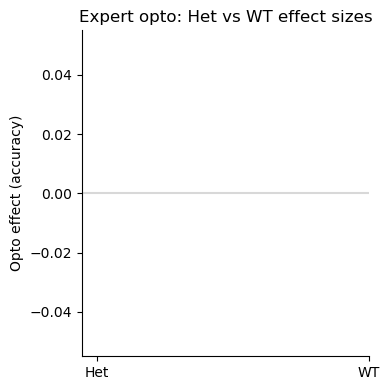

Het mean effect:  nan (n=0 sessions)
WT mean effect:   nan (n=0 sessions)
Interaction:      nan
p (het vs WT):    nan


In [16]:
# 4b: Genotype interaction plot
fig = plot_genotype_interaction(
    cohort['interaction'],
    title='Expert opto: Het vs WT effect sizes')
plt.show()

inter = cohort['interaction']
print(f'Het mean effect:  {inter["het_mean"]:.4f} '
      f'(n={len(inter["het_diffs"])} sessions)')
print(f'WT mean effect:   {inter["wt_mean"]:.4f} '
      f'(n={len(inter["wt_diffs"])} sessions)')
print(f'Interaction:      {inter["interaction"]:.4f}')
print(f'p (het vs WT):    {inter.get("p_value", np.nan):.3f}')

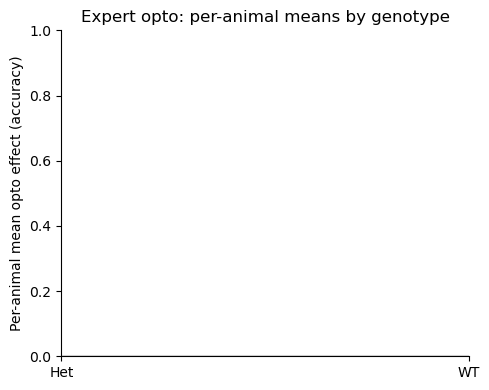

In [17]:
# 4c: Per-animal mean effects — dot plot by genotype
fig, ax = plt.subplots(figsize=(5, 4))

for geno_label, animals_dict, colour, x_pos in [
    ('Het', het_animals, OPTO_COLOUR, 0),
    ('WT', wt_animals, '#888888', 1),
]:
    means = []
    for aid in sorted(animals_dict):
        entries = [
            e for e in reports[aid]['within_session']
            if e['phase'] == OptoPhase.EXPERT_OPTO and e['effect'] is not None
        ]
        if entries:
            animal_mean = np.mean([e['effect']['diff']['accuracy'] for e in entries])
            means.append(animal_mean)

    if means:
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(means))
        ax.scatter(x_pos + jitter, means, c=colour, s=60, alpha=0.7,
                   edgecolor='white', linewidth=0.5, zorder=3)
        ax.plot([x_pos - 0.15, x_pos + 0.15],
               [np.mean(means)] * 2, color=colour, linewidth=3)

ax.axhline(0, ls='-', color='grey', alpha=0.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Het', 'WT'])
ax.set_ylabel('Per-animal mean opto effect (accuracy)')
ax.set_title('Expert opto: per-animal means by genotype')
fig.tight_layout()
plt.show()

---
## 5 — Cohort Summary: Null Prediction Testing

Test the expert-phase null prediction across multiple metrics.

**Psychometric parameters:** accuracy, PSE, slope, lapse rates
**Update matrix:** RMSE and correlation between opto and control UMs

For each metric, three complementary tests:
- **t-test** (H0: mean effect = 0) — detects whether there IS an effect
- **Mann-Whitney** — non-parametric alternative, session-level
- **TOST** (H0: |effect| ≥ bound) — positive evidence the effect is negligible

Equivalence bounds:
- Accuracy: ±0.05 (5pp — Pinto et al. 2019 report 10–15pp drops)
- PSE: ±0.10 (stimulus units on [-1, 1] scale)
- Slope: ±0.05 (sigma units)
- UM RMSE: ±0.02 (typical inter-session variability ~0.01–0.03)

In [18]:
# 5a: Null tests across all psychometric metrics (het animals only)
het_reports = {aid: reports[aid] for aid in het_animals if aid in reports}

metric_configs = {
    'accuracy': {'bound': 0.05, 'label': 'Accuracy (±0.05)'},
    'pse': {'bound': 0.10, 'label': 'PSE (±0.10)'},
    'slope': {'bound': 0.05, 'label': 'Slope (±0.05)'},
}

null_results = {}
for metric, cfg in metric_configs.items():
    null_results[metric] = expert_null_test(
        het_reports,
        metric=metric,
        equivalence_bound=cfg['bound'],
    )

# Summary table
print('Expert null prediction (het animals):')
print(f'{"Metric":<12} {"n":<4} {"Mean":<10} {"SEM":<10} '
      f'{"t-test p":<10} {"MW p":<10} {"TOST p":<10} {"Equiv?":<8}')
print('-' * 80)

for metric, cfg in metric_configs.items():
    r = null_results[metric]
    equiv = 'YES' if r['tost_reject'] else 'no'
    print(f'{metric:<12} {r["n_animals"]:<4} '
          f'{r["grand_mean"]:<10.4f} {r["grand_sem"]:<10.4f} '
          f'{r["ttest_p"]:<10.4f} '
          f'{r.get("mann_whitney_p", np.nan):<10.4f} '
          f'{r["tost_p"]:<10.4f} {equiv:<8}')

    if 'warning' in r:
        print(f'  ⚠ {r["warning"]}')

Expert null prediction (het animals):
Metric       n    Mean       SEM        t-test p   MW p       TOST p     Equiv?  
--------------------------------------------------------------------------------
accuracy     0    nan        nan        nan        nan        nan        no      
  ⚠ Only 0 animals — need >= 3 for testing.
pse          0    nan        nan        nan        nan        nan        no      
  ⚠ Only 0 animals — need >= 3 for testing.
slope        0    nan        nan        nan        nan        nan        no      
  ⚠ Only 0 animals — need >= 3 for testing.


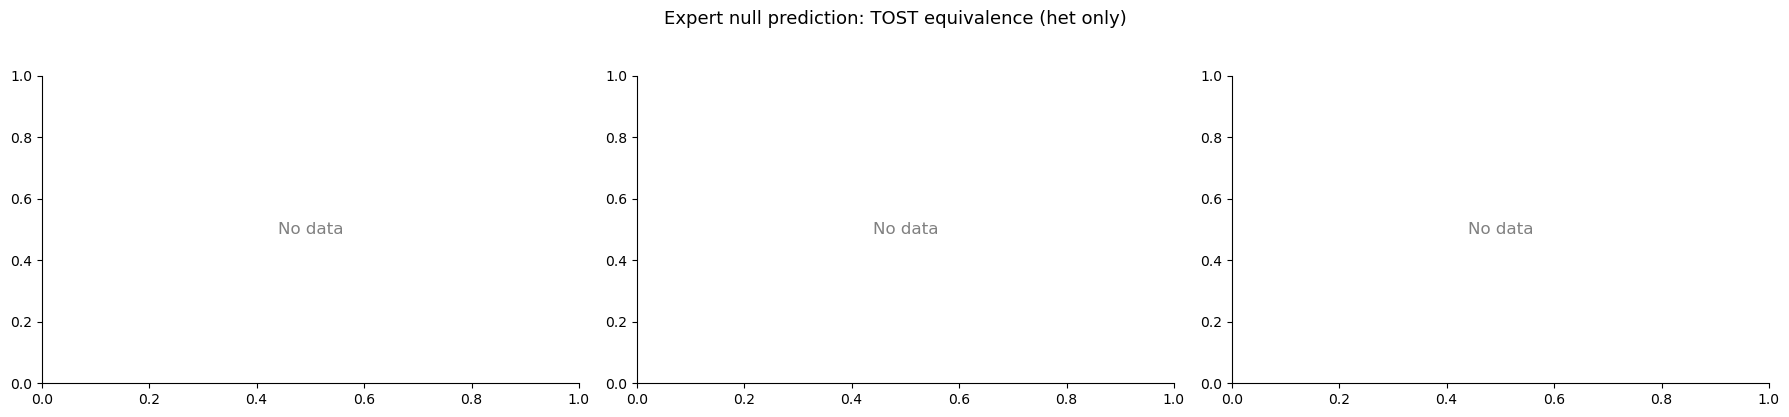

In [19]:
# 5b: Equivalence test visualisation for each metric
fig, axes = plt.subplots(1, len(metric_configs),
                         figsize=(6 * len(metric_configs), 4))
if len(metric_configs) == 1:
    axes = [axes]

for ax, (metric, cfg) in zip(axes, metric_configs.items()):
    plot_equivalence_test(
        null_results[metric], ax=ax,
        title=f'{cfg["label"]}')

fig.suptitle('Expert null prediction: TOST equivalence (het only)',
             fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

### 5c — Update Matrix Comparison

The UM is the metric used for model selection (BE vs SC) and the key
behavioural signature of distribution shifts. If opto disrupts UM structure
while leaving accuracy intact, that's evidence against dispensability.

In [20]:
from analysis.opto import expert_um_test

um_result = expert_um_test(
    opto_animals, het_reports,
    n_bins=8,
    equivalence_bound=0.02,
)

print('Expert opto: UM comparison (het animals)')
print(f'  Animals:      {um_result["n_animals"]}')
print(f'  Mean RMSE:    {um_result["rmse_mean"]:.4f}')
print(f'  Mean corr:    {um_result["corr_mean"]:.4f}')
print(f'  t-test p:     {um_result.get("ttest_p", np.nan):.4f}')
print(f'  TOST p:       {um_result.get("tost_p", np.nan):.4f} '
      f'({"EQUIVALENT" if um_result.get("tost_reject", False) else "inconclusive"})')

if 'warning' in um_result:
    print(f'  ⚠ {um_result["warning"]}')

Expert opto: UM comparison (het animals)
  Animals:      0
  Mean RMSE:    nan
  Mean corr:    nan
  t-test p:     nan
  TOST p:       nan (inconclusive)
  ⚠ Only 0 animals — need >= 3 for testing.


In [21]:
# 5d: Per-animal UM RMSE and correlation
print(f'{"Animal":<8} {"UM RMSE":<10} {"UM corr":<10} '
      f'{"n_opto":<8} {"n_ctrl":<8}')
print('-' * 50)

for aid, um_data in sorted(um_result['per_animal'].items()):
    print(f'{aid:<8} {um_data["um_rmse"]:<10.4f} '
          f'{um_data["um_corr"]:<10.4f} '
          f'{um_data["n_opto_trials"]:<8} '
          f'{um_data["n_control_trials"]:<8}')

Animal   UM RMSE    UM corr    n_opto   n_ctrl  
--------------------------------------------------


In [22]:
# 5e: UM difference heatmaps per animal
for aid, um_data in sorted(um_result['per_animal'].items()):
    fig = plot_opto_um_comparison(
        um_data['opto_um'], um_data['control_um'],
        title=f'{aid} ({opto_animals[aid].genotype}) — '
              f'RMSE={um_data["um_rmse"]:.4f}, r={um_data["um_corr"]:.3f}')
    plt.show()

In [23]:
# 5f: WT controls — same tests (should also show no effect)
wt_reports = {aid: reports[aid] for aid in wt_animals if aid in reports}

print('\nWT controls:')
print(f'{"Metric":<12} {"n":<4} {"Mean":<10} {"t-test p":<10} '
      f'{"TOST p":<10} {"Equiv?":<8}')
print('-' * 60)

for metric, cfg in metric_configs.items():
    r = expert_null_test(
        wt_reports, metric=metric,
        equivalence_bound=cfg['bound'])
    equiv = 'YES' if r['tost_reject'] else 'no'
    print(f'{metric:<12} {r["n_animals"]:<4} '
          f'{r["grand_mean"]:<10.4f} {r["ttest_p"]:<10.4f} '
          f'{r["tost_p"]:<10.4f} {equiv:<8}')

# UM test on WT
wt_um = expert_um_test(
    opto_animals, wt_reports, n_bins=8, equivalence_bound=0.02)
print(f'{"UM RMSE":<12} {wt_um["n_animals"]:<4} '
      f'{wt_um["rmse_mean"]:<10.4f} '
      f'{wt_um.get("ttest_p", np.nan):<10.4f} '
      f'{wt_um.get("tost_p", np.nan):<10.4f} '
      f'{"YES" if wt_um.get("tost_reject", False) else "no":<8}')


WT controls:
Metric       n    Mean       t-test p   TOST p     Equiv?  
------------------------------------------------------------
accuracy     0    nan        nan        nan        no      
pse          0    nan        nan        nan        no      
slope        0    nan        nan        nan        no      
UM RMSE      0    nan        nan        nan        no      


### Interpretation guide

**For the null prediction to be supported:**
- Standard tests (t-test, MW) should be non-significant for ALL metrics
- TOST should reject (equivalent) for at least accuracy and UM RMSE
- UM correlation should be high (>0.9) between opto and control
- WT controls should also show no effects (validates masking)

**Warning signs:**
- Significant t-test on ANY metric → opto has an effect → null prediction fails
- Non-significant t-test + non-significant TOST → underpowered, collect more data
- Accuracy null but UM disrupted → PPC affects update computation without affecting current-trial accuracy

---
## 6 — Additional Analyses

### 6a — Stimulus-conditional opto effects

Is the opto effect larger for ambiguous stimuli (near boundary) vs easy stimuli (far from boundary)?
If PPC is dispensable, the effect should be null everywhere.

In [24]:
def stimulus_conditional_effect(session, boundary_zone=0.3):
    """
    Split opto effect by stimulus difficulty.

    Ambiguous: |stimulus| < boundary_zone
    Easy: |stimulus| >= boundary_zone
    """
    opto_mask, ctrl_mask = split_trials_by_opto(session)
    stim = session.trials.stimulus
    choice = session.trials.choice.astype(float)
    cat = session.trials.category
    valid = ~session.trials.abort & ~np.isnan(choice)

    results = {}
    for label, zone_mask in [
        ('ambiguous', np.abs(stim) < boundary_zone),
        ('easy', np.abs(stim) >= boundary_zone),
    ]:
        opto_sel = opto_mask & zone_mask & valid
        ctrl_sel = ctrl_mask & zone_mask & valid
        if opto_sel.sum() < 5 or ctrl_sel.sum() < 5:
            results[label] = {'diff': np.nan, 'n_opto': 0, 'n_ctrl': 0}
            continue

        opto_acc = np.mean(choice[opto_sel] == cat[opto_sel])
        ctrl_acc = np.mean(choice[ctrl_sel] == cat[ctrl_sel])
        results[label] = {
            'opto_acc': float(opto_acc),
            'ctrl_acc': float(ctrl_acc),
            'diff': float(opto_acc - ctrl_acc),
            'n_opto': int(opto_sel.sum()),
            'n_ctrl': int(ctrl_sel.sum()),
        }
    return results


# Run for all expert opto sessions
print(f'{"Animal":<8} {"Geno":<6} {"Ambig Δacc":<14} {"Easy Δacc":<14} '
      f'{"Ambig>Easy?":<12}')
print('-' * 60)

for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']
    ambig_diffs, easy_diffs = [], []

    for sess, phase in zip(animal.sessions, phases):
        if phase != OptoPhase.EXPERT_OPTO:
            continue
        sc = stimulus_conditional_effect(sess)
        if not np.isnan(sc['ambiguous']['diff']):
            ambig_diffs.append(sc['ambiguous']['diff'])
        if not np.isnan(sc['easy']['diff']):
            easy_diffs.append(sc['easy']['diff'])

    if ambig_diffs and easy_diffs:
        a_mean = np.mean(ambig_diffs)
        e_mean = np.mean(easy_diffs)
        bigger = 'yes' if abs(a_mean) > abs(e_mean) else 'no'
        print(f'{aid:<8} {animal.genotype:<6} {a_mean:<14.4f} '
              f'{e_mean:<14.4f} {bigger:<12}')

Animal   Geno   Ambig Δacc     Easy Δacc      Ambig>Easy? 
------------------------------------------------------------
SS01     unknown 0.0505         0.0661         no          
SS04     unknown 0.2567         0.0910         yes         
SS10     unknown 0.2072         0.0417         yes         
SS11     unknown 0.2753         -0.1096        yes         
SS13     unknown -0.1102        0.0210         yes         


### 6b — No-response rate under opto

Elevated no-responses under opto would suggest motor/engagement disruption
rather than (or in addition to) cognitive effects.

In [25]:
print(f'{"Animal":<8} {"Geno":<6} {"NR_opto%":<10} {"NR_ctrl%":<10} '
      f'{"Δ_NR%":<10} {"n_sess":<8}')
print('-' * 55)

for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']

    opto_nr, ctrl_nr, n_sess = [], [], 0
    for sess, phase in zip(animal.sessions, phases):
        if phase != OptoPhase.EXPERT_OPTO:
            continue
        n_sess += 1
        nr = sess.trials.no_response
        opto_on = sess.trials.opto_on
        valid = ~sess.trials.abort

        opto_trials = opto_on & valid
        ctrl_trials = ~opto_on & valid

        if opto_trials.sum() > 0:
            opto_nr.append(nr[opto_trials].mean())
        if ctrl_trials.sum() > 0:
            ctrl_nr.append(nr[ctrl_trials].mean())

    if opto_nr and ctrl_nr:
        o_mean = 100 * np.mean(opto_nr)
        c_mean = 100 * np.mean(ctrl_nr)
        print(f'{aid:<8} {animal.genotype:<6} {o_mean:<10.1f} '
              f'{c_mean:<10.1f} {o_mean - c_mean:<10.1f} {n_sess:<8}')

Animal   Geno   NR_opto%   NR_ctrl%   Δ_NR%      n_sess  
-------------------------------------------------------
SS01     unknown 0.0        0.0        0.0        1       
SS04     unknown 0.0        0.0        0.0        1       
SS10     unknown 0.0        0.0        0.0        1       
SS11     unknown 0.0        0.0        0.0        1       
SS13     unknown 0.0        0.0        0.0        1       


### 6c — Reaction time under opto

Slower RT under opto could indicate decision uncertainty even if accuracy is preserved.

In [26]:
print(f'{"Animal":<8} {"Geno":<6} {"RT_opto":<10} {"RT_ctrl":<10} '
      f'{"Δ_RT":<10} {"p (MW)":<10}')
print('-' * 60)

for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']

    all_opto_rt, all_ctrl_rt = [], []
    for sess, phase in zip(animal.sessions, phases):
        if phase != OptoPhase.EXPERT_OPTO:
            continue
        rt = sess.trials.reaction_time
        valid = sess.trials.valid_mask
        opto_on = sess.trials.opto_on

        opto_rt = rt[valid & opto_on]
        ctrl_rt = rt[valid & ~opto_on]

        # Filter out NaN RTs
        opto_rt = opto_rt[~np.isnan(opto_rt)]
        ctrl_rt = ctrl_rt[~np.isnan(ctrl_rt)]

        all_opto_rt.extend(opto_rt)
        all_ctrl_rt.extend(ctrl_rt)

    all_opto_rt = np.array(all_opto_rt)
    all_ctrl_rt = np.array(all_ctrl_rt)

    if len(all_opto_rt) < 5 or len(all_ctrl_rt) < 5:
        continue

    o_med = np.median(all_opto_rt)
    c_med = np.median(all_ctrl_rt)
    try:
        _, p = mannwhitneyu(all_opto_rt, all_ctrl_rt, alternative='two-sided')
    except Exception:
        p = np.nan

    print(f'{aid:<8} {animal.genotype:<6} {o_med:<10.3f} '
          f'{c_med:<10.3f} {o_med - c_med:<10.3f} {p:<10.3f}')

Animal   Geno   RT_opto    RT_ctrl    Δ_RT       p (MW)    
------------------------------------------------------------
SS01     unknown 0.000      0.000      0.000      0.930     
SS04     unknown 216.000    241.000    -25.000    0.548     
SS10     unknown 1757.500   24.500     1733.000   0.034     
SS11     unknown 0.000      0.000      0.000      0.464     
SS13     unknown 0.000      0.000      0.000      0.069     


### 6d — Response bias under opto

Does opto shift the response bias (PSE) rather than impairing discrimination (slope)?
A bias shift without slope change would suggest PPC affects criterion, not sensitivity.

In [27]:
print(f'{"Animal":<8} {"Geno":<6} {"Δ_PSE":<10} {"Δ_slope":<10} '
      f'{"Δ_lapse_L":<10} {"Δ_lapse_H":<10}')
print('-' * 60)

for aid in sorted(opto_animals):
    entries = [
        e for e in reports[aid]['within_session']
        if e['phase'] == OptoPhase.EXPERT_OPTO and e['effect'] is not None
    ]
    if not entries:
        continue

    pse_diffs = [e['effect']['diff'].get('pse', np.nan) for e in entries]
    slope_diffs = [e['effect']['diff'].get('slope', np.nan) for e in entries]
    lapse_l = [
        e['effect']['opto_stats'].get('lapse_low', np.nan)
        - e['effect']['control_stats'].get('lapse_low', np.nan)
        for e in entries
    ]
    lapse_h = [
        e['effect']['opto_stats'].get('lapse_high', np.nan)
        - e['effect']['control_stats'].get('lapse_high', np.nan)
        for e in entries
    ]

    print(f'{aid:<8} {opto_animals[aid].genotype:<6} '
          f'{np.nanmean(pse_diffs):<10.4f} '
          f'{np.nanmean(slope_diffs):<10.4f} '
          f'{np.nanmean(lapse_l):<10.4f} '
          f'{np.nanmean(lapse_h):<10.4f}')

Animal   Geno   Δ_PSE      Δ_slope    Δ_lapse_L  Δ_lapse_H 
------------------------------------------------------------
SS01     unknown 0.2010     -0.0172    0.0058     -0.1612   
SS04     unknown -0.0290    0.0000     0.0086     -0.1663   
SS10     unknown -1.6335    -0.3056    -0.4837    0.1656    
SS11     unknown -0.3678    0.3028     -0.1565    0.1874    
SS13     unknown 0.1448     0.1453     -0.1018    0.0000    


### 6e — Carry-over effects

Does an opto trial affect performance on the immediately following (non-opto) trial?
If carry-over is large, the 30% interleaved design contaminates control trials.

In [28]:
def compute_carryover(session):
    """
    Compare accuracy on control trials that follow an opto trial
    vs control trials that follow another control trial.
    """
    trials = session.trials
    valid = trials.valid_mask
    opto = trials.opto_on
    correct = trials.correct

    post_opto_acc, post_ctrl_acc = [], []
    for t in range(1, len(valid)):
        if not valid[t] or opto[t]:  # current trial must be valid control
            continue
        if not valid[t - 1]:  # previous trial must be valid
            continue

        if opto[t - 1]:  # previous was opto
            post_opto_acc.append(correct[t])
        else:  # previous was control
            post_ctrl_acc.append(correct[t])

    if len(post_opto_acc) < 5 or len(post_ctrl_acc) < 5:
        return None

    return {
        'post_opto_acc': float(np.mean(post_opto_acc)),
        'post_ctrl_acc': float(np.mean(post_ctrl_acc)),
        'diff': float(np.mean(post_opto_acc) - np.mean(post_ctrl_acc)),
        'n_post_opto': len(post_opto_acc),
        'n_post_ctrl': len(post_ctrl_acc),
    }


print(f'{"Animal":<8} {"Geno":<6} {"Post-opto":<12} {"Post-ctrl":<12} '
      f'{"Δ":<10} {"n_po":<8} {"n_pc":<8}')
print('-' * 70)

all_diffs = []
for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    phases = reports[aid]['phases']

    animal_diffs = []
    for sess, phase in zip(animal.sessions, phases):
        if phase != OptoPhase.EXPERT_OPTO:
            continue
        co = compute_carryover(sess)
        if co is not None:
            animal_diffs.append(co['diff'])

    if animal_diffs:
        mean_diff = np.mean(animal_diffs)
        all_diffs.append(mean_diff)
        # Pool for display
        po_accs = []
        pc_accs = []
        for sess, phase in zip(animal.sessions, phases):
            if phase != OptoPhase.EXPERT_OPTO:
                continue
            co = compute_carryover(sess)
            if co:
                po_accs.append(co['post_opto_acc'])
                pc_accs.append(co['post_ctrl_acc'])
        print(f'{aid:<8} {animal.genotype:<6} '
              f'{np.mean(po_accs):<12.4f} '
              f'{np.mean(pc_accs):<12.4f} '
              f'{mean_diff:<10.4f}')

if len(all_diffs) >= 3:
    t, p = ttest_1samp(all_diffs, 0)
    print(f'\nCohort carry-over test: mean={np.mean(all_diffs):.4f}, '
          f't={t:.2f}, p={p:.3f}')

Animal   Geno   Post-opto    Post-ctrl    Δ          n_po     n_pc    
----------------------------------------------------------------------
SS01     unknown 0.7722       0.6735       0.0987    
SS04     unknown 0.6667       0.6250       0.0417    
SS10     unknown 0.4865       0.6125       -0.1260   
SS11     unknown 0.6957       0.5962       0.0995    
SS13     unknown 0.8113       0.6667       0.1447    

Cohort carry-over test: mean=0.0517, t=1.09, p=0.336


---
## 7 — Full Animal Reports

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


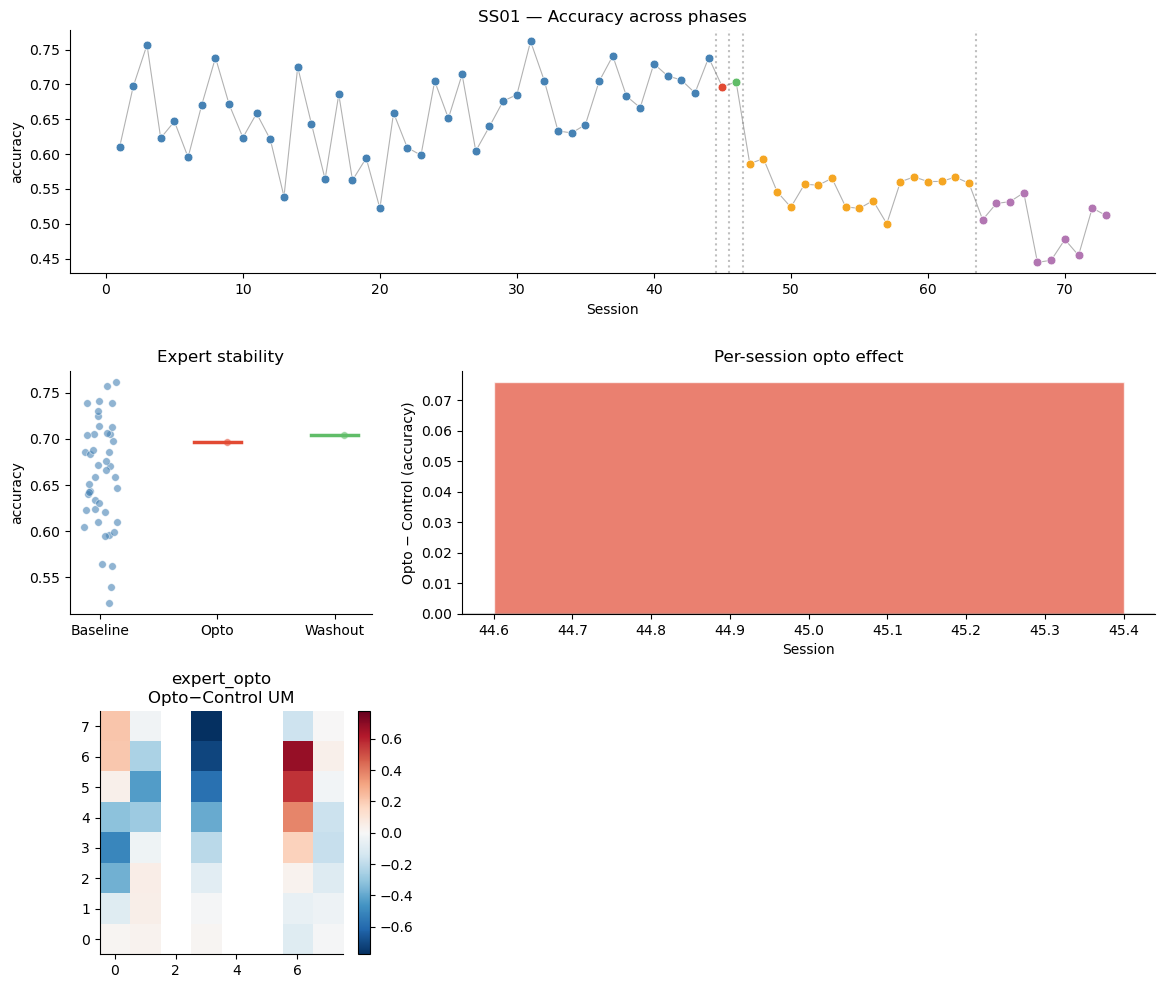

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


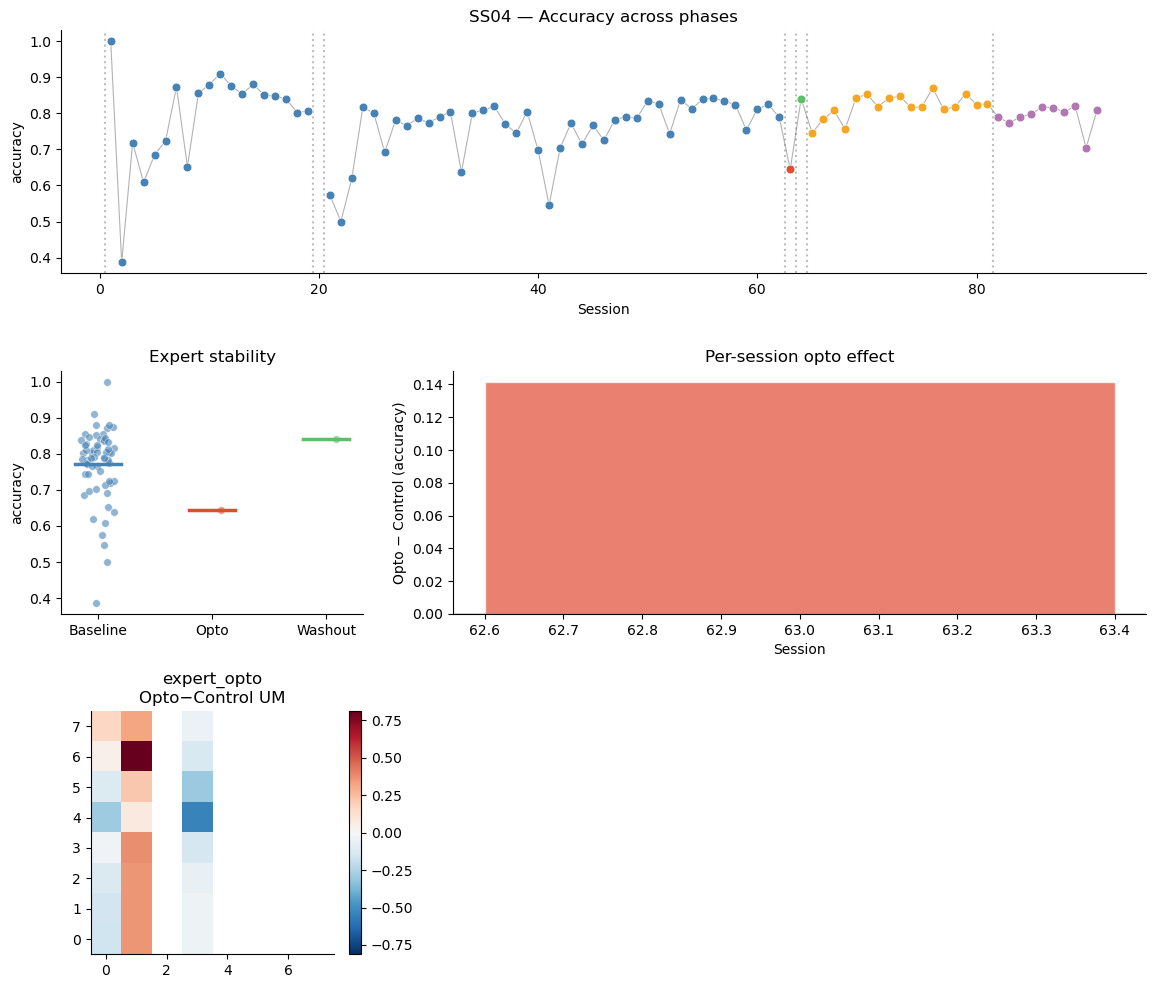

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/plotting/opto.py:703: RuntimeWarning: All-NaN sli

KeyboardInterrupt: 

In [29]:
for aid in sorted(opto_animals):
    animal = opto_animals[aid]
    report = reports[aid]
    fig = plot_animal_opto_report(animal, report)
    plt.show()
    print()